

#*Proyecto Integrador : ASISTIR EN UNA ENFERMEDAD*





<div style="
background-color:#e8f5e9;
border:3px solid #4caf50;
padding:20px;
border-radius:15px;
text-align:center;
color:#1b5e20;">

<h2>📊 Ciencia de Datos y Optimización de Sistemas</h2>

<p><b>Carrera:</b> Tecnicatura Universitaria en Ciencia de Datos e IA</p>

<p><b>Profesora:</b> Amalia Guaymas Canavire</p>

<p><b>Alumnos:</b><br>
Quispe Alejandra Carina<br>
Arzola Franco Javier<br>
Peloc Natalia Zulema<br>
Lemos Federico
</p>

</div>

##1. Comprensión del Problema
###1.1 Contexto

  
Las enfermedades cardiovasculares son un grupo de trastornos del corazón y de los vasos sanguíneos. Según la Organización Mundial de la Salud (OMS), representan la principal causa de muerte en todo el mundo. Muchos de estos eventos podrían prevenirse actuando sobre factores de riesgo modificables.

En el ámbito de la ciencia de datos aplicada a la salud, la capacidad de identificar patrones y factores de riesgo mediante el Análisis Exploratorio de Datos (EDA) es fundamental para:

*   Identificar grupos de riesgo de manera temprana.
*   Entender la correlación entre variables biológicas (como la edad o el colesterol) y la presencia de patologías.
*   Optimizar la toma de decisiones clínicas mediante modelos predictivos basados en evidencia estadística.


### 1.2 Problemas

A pesar de los avances médicos, la detección temprana de anomalías cardíacas sigue siendo un reto debido a la complejidad y la interacción de múltiples factores (genéticos, conductuales y clínicos). La falta de un análisis integrado de estos datos puede llevar a diagnósticos tardíos o a una gestión ineficiente de los recursos sanitarios.

### 1.3 Objetivo del Proyecto
### 1.3.1 Objetivo General y Uso del Conjunto de Datos

El objetivo central de este proyecto es el desarrollo y evaluación de un modelo predictivo de clasificación binaria. En este contexto, el modelo tiene la tarea de predecir una etiqueta específica que pertenece a una de dos clases posibles: paciente cardíaco o no cardíaco.

Para lograr esto, entrenaremos un clasificador binario utilizando el conjunto de datos clínicos y estilos de vida, permitiendo que el sistema aprenda a distinguir patrones entre ambas categorías basándose en las variables de entrada (como edad, presión arterial y niveles de colesterol).

### 1.3.2 Propósito y Alcance del Modelo

El desarrollo de este modelo predictivo busca impactar positivamente en el entorno sanitario a través de:


*   **Identificación de pacientes de riesgo**: Detectar de manera proactiva a individuos que presenten una alta probabilidad de padecer enfermedades cardiovasculares basándose en sus indicadores clínicos.
*  **Apoyo a la toma de decisiones clínicas**: Servir como una herramienta de soporte para que el personal médico cuente con una segunda opinión basada en datos al momento de priorizar casos.
*   **Asistencia, no diagnóstico**: Es fundamental establecer que este modelo no realiza diagnósticos médicos. Su función es actuar como un sistema de asistencia y alerta temprana; el diagnóstico final y definitivo siempre recae en el juicio profesional del médico responsable.










### 1.4 Diccionario de variables presentes

* Edad (age): Registrada en días. Para el análisis, voy a convertirlo en años dividiendo por $365.25$ para que sea más fácil de interpretar.
* Altura (height): Estatura del paciente expresada en centímetros (cm).
* Peso (weight): Peso del paciente expresado en kilogramos (kg).
* Género (gender): Variable categórica codificada que identifica el sexo del paciente.Donde 0(masculino) y 1(femenino)
* Presión Arterial Sistólica (ap_hi): Indica la presión durante el latido y es crucial para evaluar riesgos cardiovasculares. Una presión sistólica saludable en adultos es inferior a 120 y se considera elevada entre \(120-129\) y alta de \(130-139\).
* Presión Arterial Diastólica (ap_lo): El valor mínimo de presión arterial entre latidos.Normal: Menos de 80.Elevada: 80-89.Hipertensión Etapa 1: 80-89.Hipertensión Etapa 2: 90 o más.
* Colesterol (cholesterol): Variable categórica con tres niveles: 0 (normal), 1 (por encima de lo normal) y 2 (muy por encima de lo normal).
* Glucosa (gluc): Niveles de azúcar en sangre, categorizados igual que el colesterol: 1 (normal), 2 (alto) y 3 (muy alto).
* Fumar (smoke): Variable binaria que indica si el paciente fuma o no.
* Ingesta de alcohol (alco): Variable binaria que indica si el paciente consume alcohol.
* Actividad física (active): Variable binaria que indica si el paciente realiza actividad física regularmente.
* Enfermedad Cardiovascular (cardio): Variable binaria donde se indica la presencia (1) o ausencia (0) de la patología.

## 2. Analisis exploratorio de Datos
#### 2a. Carga de Datos

Este dataset fue descargado de la pagina de Kaggle al drive en la carpeta datos lo guardo utilizando la libreria de pandas y verifico si esta cargado correctamente visualizando los 5 primeros r egistros.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
import os

# 1. Definimos la ruta al archivo
ruta_archivo = "/content/drive/MyDrive/Tp1_QuispeAlejandra/Data/health_data.csv"
# 2. Cargamos el dataset directamente
cardio_df = pd.read_csv(ruta_archivo)

# 3. Verificamos
print("Dataset cargado con éxito.")
cardio_df.head()


Dataset cargado con éxito.


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


####Exploración Inicial

Por una cuestion de comodidad cambio el nombre de las columnas en el data frame, para poder trabajar sin problemas.

In [4]:
# 1. Renombrar todas las columnas al castellano
cardio_df.rename(columns={
    'Unnamed: 0': 'indice_original',
    'id': 'id_paciente',
    'age': 'edad',
    'gender': 'genero',
    'height': 'altura',
    'weight': 'peso',
    'ap_hi': 'presion_sistolica',
    'ap_lo': 'presion_diastolica',
    'cholesterol': 'colesterol',
    'gluc': 'glucosa',
    'smoke': 'fuma',
    'alco': 'alcohol',
    'active': 'activo',
    'cardio': 'cardio'
}, inplace=True)

# 3. Vista rápida de los nuevos nombres
cardio_df.head()
# me fijo si se cargo bien y saber la cantidad de filas uy columnas
cardio_df.shape # (70000,14)

(70000, 14)

¿Qué atributos o variables contiene mi conjunto de datos?¿Cuáles son numéricas o categóricas?

In [ ]:
cardio_df.tail()


,indice_original,id_paciente,edad,genero,altura,peso,presion_sistolica,presion_diastolica,colesterol,glucosa,fuma,alcohol,activo,cardio
69995,69995,99993.0,19240.0,1,168.0,76.0,120.0,80.0,0,0,1,0,1,0
69996,69996,99995.0,22601.0,0,158.0,126.0,140.0,90.0,1,1,0,0,1,1
69997,69997,99996.0,19066.0,1,183.0,105.0,180.0,90.0,2,0,0,1,0,1
69998,69998,99998.0,22431.0,0,163.0,72.0,135.0,80.0,0,1,0,0,0,1
69999,69999,99999.0,20540.0,0,170.0,72.0,120.0,80.0,1,0,0,0,1,0


In [ ]:
cardio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   indice_original     70000 non-null  int64  
 1   id_paciente         70000 non-null  float64
 2   edad                70000 non-null  float64
 3   genero              70000 non-null  int64  
 4   altura              70000 non-null  float64
 5   peso                70000 non-null  float64
 6   presion_sistolica   70000 non-null  float64
 7   presion_diastolica  70000 non-null  float64
 8   colesterol          70000 non-null  int64  
 9   glucosa             70000 non-null  int64  
 10  fuma                70000 non-null  int64  
 11  alcohol             70000 non-null  int64  
 12  activo              70000 non-null  int64  
 13  cardio              70000 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 7.5 MB


* El dataset tiene 70.000 registros y 14 variables. Según la información obtenida, hay 2 variables que no son informativas para el análisis predictivo, y todas las variables están codificadas como numéricas; sin embargo, algunas de ellas (como género, colesterol, glucosa, fuma, alcohol, activo y cardio) son en realidad variables categóricas o binarias que serán tratadas como tales en el análisis.



* La variable objetivo, salida esperada del modelo, ($y$) es *cardio*. Esta clase tiene dos valores:
  * 1 -> Presencia de patologia cardiaca.
  * 0 -> Ausencia de patologia cardiaca.
* No se observan valores faltantes en estas primeras lecturas.

Antes de analizar los datos, se eliminan 2 columnas no informativas para el análisis predictivo y se convierte la variable *edad* de días a años. Esto permite una interpretación más clara de los resultados y evita posibles distorsiones en el análisis exploratorio.


In [5]:
# 1. Pasamos la edad de días a años
# Dividimos por 365.25 para considerar años bisiestos y convertimos a entero
cardio_df['edad'] = (cardio_df['edad'] / 365.25).astype(int)

# 2. Borramos las columnas que no sirven para el análisis predictivo
# Usamos el parámetro 'columns' para especificar cuáles y 'inplace=True' para que el cambio sea fijo
cardio_df.drop(columns=['id_paciente', 'indice_original'], inplace=True,errors='ignore')

# 3. Verifico como quedo el dataset
print("Nuevas dimensiones:", cardio_df.shape)
cardio_df.head()

Nuevas dimensiones: (70000, 12)


,edad,genero,altura,peso,presion_sistolica,presion_diastolica,colesterol,glucosa,fuma,alcohol,activo,cardio
0,50,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,55,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,51,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,48,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,47,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


### 2b. Tipos de Variables
* Edad(cuantitativa)
* Altura (cuantitativa)
* Peso (cuantitativa)
* Genero (cualitativa)
* presion_sistolica (cuantitativa)
* presion_diastolica (cuantitativa)
* colesterol(categorica)
* glucosa (categorica)
* fuma (categorica binaria)
* alcohol (categorica binaria)
* activo (categorica binaria)
* cardio (categorica binaria)

### Preguntas que nos hacemos ahora que tenemos los datos listos

#### 1. Distribución y Balance
¿Cómo se distribuye la enfermedad cardiovascular en la muestra?
¿Cuál es la edad promedio del paciente en el dataset?

#### 2. Factores de Riesgo Clínicos (Examen)
¿Existe una relación directa entre la hipertensión(pd/ps)y el riesgo cardíaco? (Aquí comparo presion_sistolica y presion_diastolica entre pacientes con cardio=0 y cardio=1).

¿Cómo influyen los niveles de colesterol y glucosa en la presencia de la enfermedad? (Dado que estas variables tienen niveles 1, 2 y 3, puedes ver si el riesgo aumenta drásticamente en el nivel 3).

#### 3. Factores Demográficos y Físicos
¿A partir de qué edad se dispara la frecuencia de pacientes cardíacos? (Al haber convertido la edad a años, crear rangos de edades para ver el factor de riesgo por década).

¿Hay diferencias significativas entre géneros respecto a la presencia de la enfermedad?

¿Cómo se relaciona el Índice de Masa Corporal (IMC) con el estado cardiovascular? (no tienes IMC,calcularlo con peso y altura para responder esta pregunta).

#### 4. Hábitos y Estilo de Vida (Subjetivas)
¿Tienen los fumadores o los consumidores de alcohol una mayor proporción de diagnósticos positivos?

¿Qué tanto "protege" la actividad física (activo) a los pacientes en este dataset? (Comparar la tasa de enfermedad entre personas activas vs. sedentarias).

#### 5. Análisis Multivariable (Para el Modelo Predictivo)
¿Cuál es la combinación de factores más peligrosa? (Por ejemplo: ¿Es peor ser fumador con colesterol alto o tener presión alta siendo sedentario?).

¿Existen valores atípicos (outliers) en las presiones arteriales que puedan sesgar el entrenamiento del modelo?.

#### **¿Cómo se distribuye la enfermedad cardiovascular en la muestra? ¿Cuál es la edad promedio del paciente en el dataset?**

In [7]:
cardio_df.describe(include= 'all').T # Estadística descriptiva

,count,mean,std,min,25%,50%,75%,max
edad,70000.0,52.803257,6.762462,29.0,48.0,53.0,58.0,64.0
genero,70000.0,0.349571,0.476838,0.0,0.0,0.0,1.0,1.0
altura,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
peso,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
presion_sistolica,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
presion_diastolica,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
colesterol,70000.0,0.366871,0.680250,0.0,0.0,0.0,1.0,2.0
glucosa,70000.0,0.226457,0.572270,0.0,0.0,0.0,0.0,2.0
fuma,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alcohol,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0


OBSERVACIONES

**Observaciones del análisis descriptivo:**

* La distribución de la variable objetivo *cardio* está balanceada entre pacientes con y sin la patología, lo cual es favorable para el entrenamiento de modelos de clasificación.
* La edad promedio de los pacientes es de aproximadamente 53 años, con un valor mínimo de 29 y un máximo de 64. El 75 % de los pacientes tiene hasta 58 años, lo que indica que la muestra está concentrada en adultos de mediana edad y adultos mayores.
* La variable colesterol presenta 3 categorías; el valor más frecuente corresponde al nivel 2 (por encima de lo normal).
* Se detecta un valor mínimo negativo en la presión sistólica, lo cual es fisiológicamente imposible. Este tipo de registros debe tratarse como error de calidad de datos y será analizado con mayor detalle.
* La variable de presión diastólica también presenta valores que requieren revisión.
* Se registran pacientes con altura de 55 cm y peso mínimo de 10 kg, valores inconsistentes para una población adulta que probablemente corresponden a errores de carga de datos.


In [9]:
#!pip install ydata_profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(cardio_df, title="Cardiaco", explorative=True)
ruta_reporte= "/content/drive/MyDrive/Tp1_QuispeAlejandra/Data/reporte_cardio.html"
profile.to_file(ruta_reporte) # Te lo guarda local
profile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.5 MB/s eta 0:00:00


/tmp/ipykernel_34063/459955375.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 22.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### ¿Como se distribuyen las variables?
##### Voy a comenzar con mi variable objetivo

In [12]:

# 2. Verificación de las clases para el objetivo (Clasificación Binaria)
print("--- Verificación de balance de datos ---")
conteo_clases = cardio_df['cardio'].value_counts()
porcentaje_clases = cardio_df['cardio'].value_counts(normalize=True) * 100

print(conteo_clases)
print(f"\nPorcentaje de clases:\n{porcentaje_clases.round(2)}")

--- Verificación de balance de datos ---
cardio
0    35021
1    34979
Name: count, dtype: int64

Porcentaje de clases:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


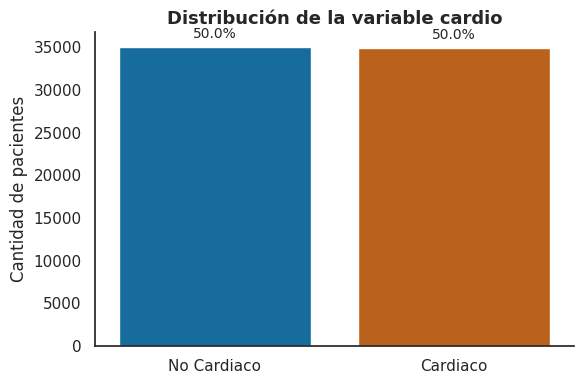

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = ['#0072B2', '#D55E00']

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=cardio_df,
    x='cardio',
    hue='cardio',
    palette=palette,
    legend=False,
    ax=ax
)

# Labels correctos
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Cardiaco', 'Cardiaco'])

# Quitar bordes
sns.despine()

# Porcentajes
total = len(cardio_df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{height/total*100:.1f}%'
    ax.text(
        p.get_x() + p.get_width()/2,
        height + total*0.01,
        percentage,
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Distribución de la variable cardio', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de pacientes')

plt.tight_layout()
plt.show()

Se observa que la distribución de la variable objetivo está balanceada: aproximadamente el 50 % de los pacientes presenta la enfermedad cardiovascular y el otro 50 % no. Esta característica es favorable para el entrenamiento de modelos de clasificación, ya que reduce el riesgo de sesgo hacia la clase mayoritaria.


In [14]:
bin_cols = [
    col for col in cardio_df.columns
    if cardio_df[col].nunique() == 2
] # Seleccionar variables binarias
print("Variables binarias:",bin_cols)


num_cols = cardio_df.select_dtypes(include=['number']).columns # seleccionar variables númericas . “Que una variable tenga números no significa que sea numérica en el sentido estadístico”
num_cols = [col for col in num_cols if col not in bin_cols]
print("variables numéricas:",num_cols)

cat_cols = cardio_df.select_dtypes(include=['object', 'category']).columns # seleccionar variables categóricas
print("Variables categóricas:",cat_cols)

Variables binarias: ['genero', 'fuma', 'alcohol', 'activo', 'cardio']
variables numéricas: ['edad', 'altura', 'peso', 'presion_sistolica', 'presion_diastolica', 'colesterol', 'glucosa']
Variables categóricas: Index([], dtype='object')


Se identificaron 5 variables binarias, 7 variables numéricas y ninguna variable de tipo objeto o categoría explícita. A continuación se analiza la distribución de cada grupo de variables.


### Variables numéricas

Se exploran las variables numéricas de mayor interés para el análisis, comenzando por su distribución individual mediante histogramas.


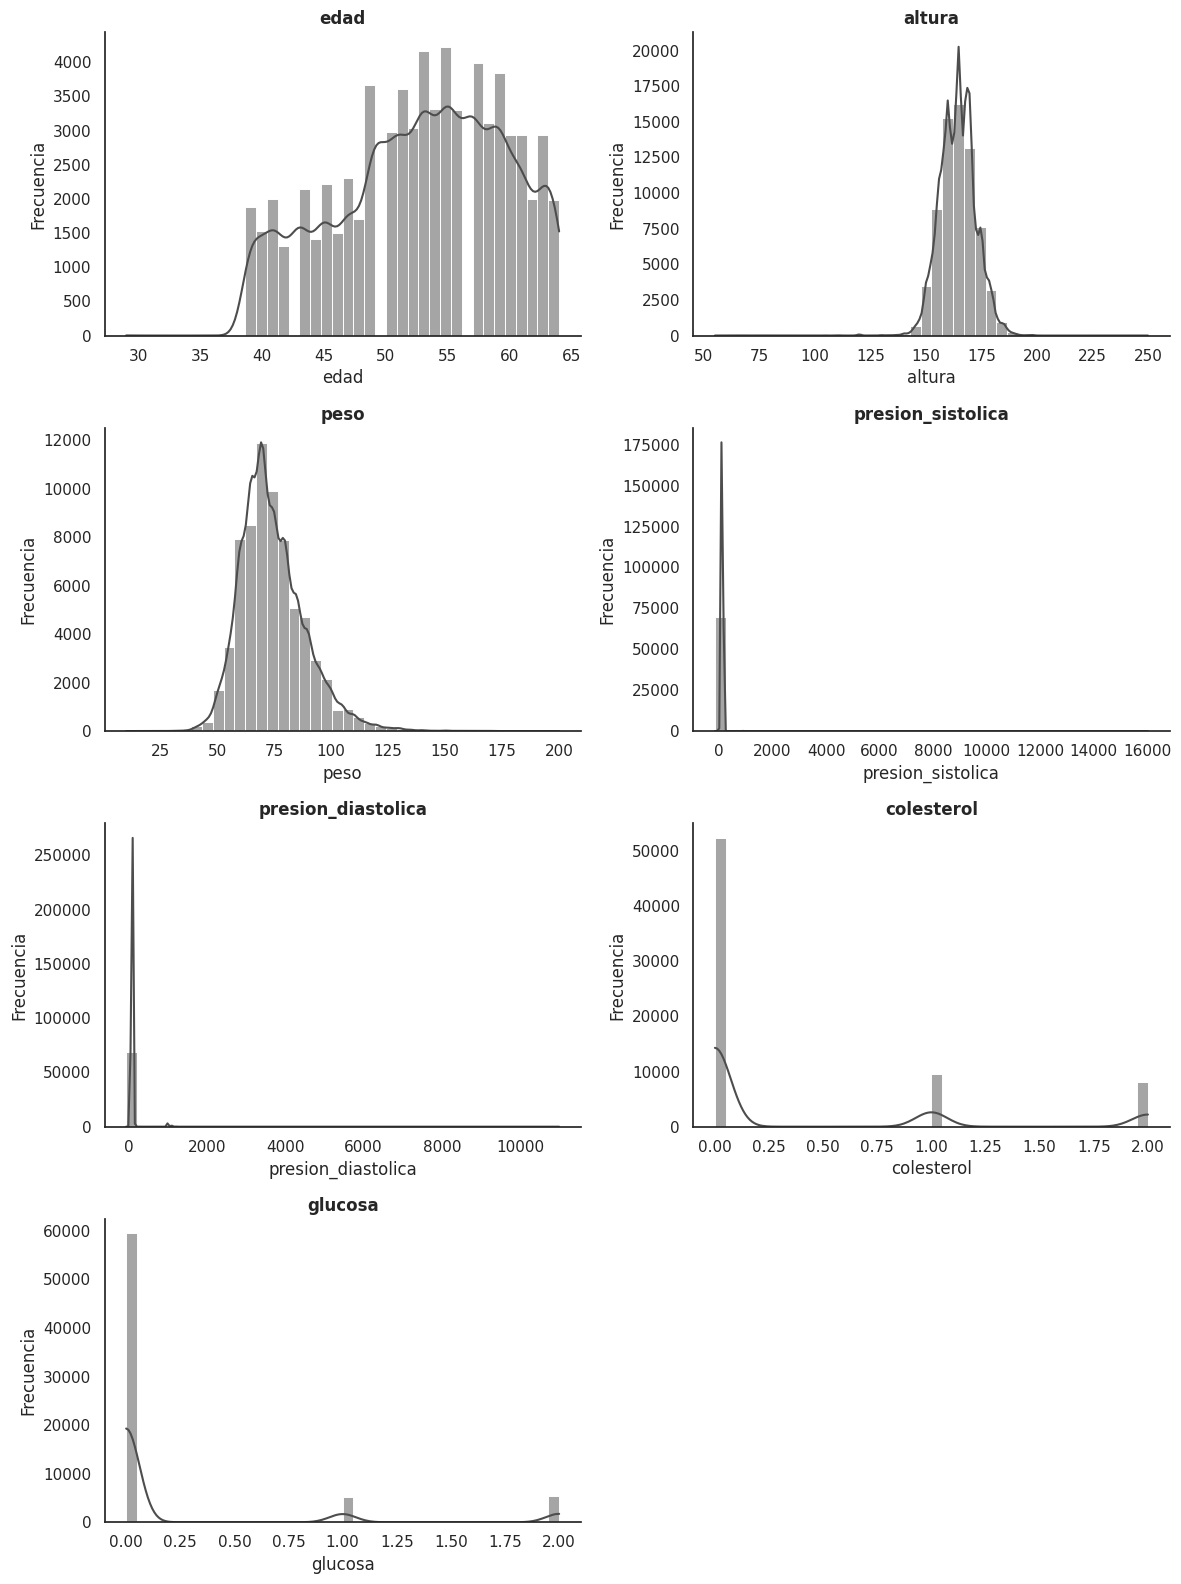

In [15]:
import math

# Definir columnas según tu lista
num_cols = ['edad', 'altura', 'peso', 'presion_sistolica', 'presion_diastolica', 'colesterol', 'glucosa']

n_cols_graf = 2
n_filas_graf = math.ceil(len(num_cols) / n_cols_graf)

fig, axes = plt.subplots(n_filas_graf, n_cols_graf, figsize=(12, n_filas_graf * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=cardio_df,
        x=col,
        bins=40,
        kde=True,
        color='#4D4D4D',
        ax=axes[i]
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')

# Ocultar el espacio vacío que sobra (el 8vo)
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

sns.despine()
plt.tight_layout()
plt.show()

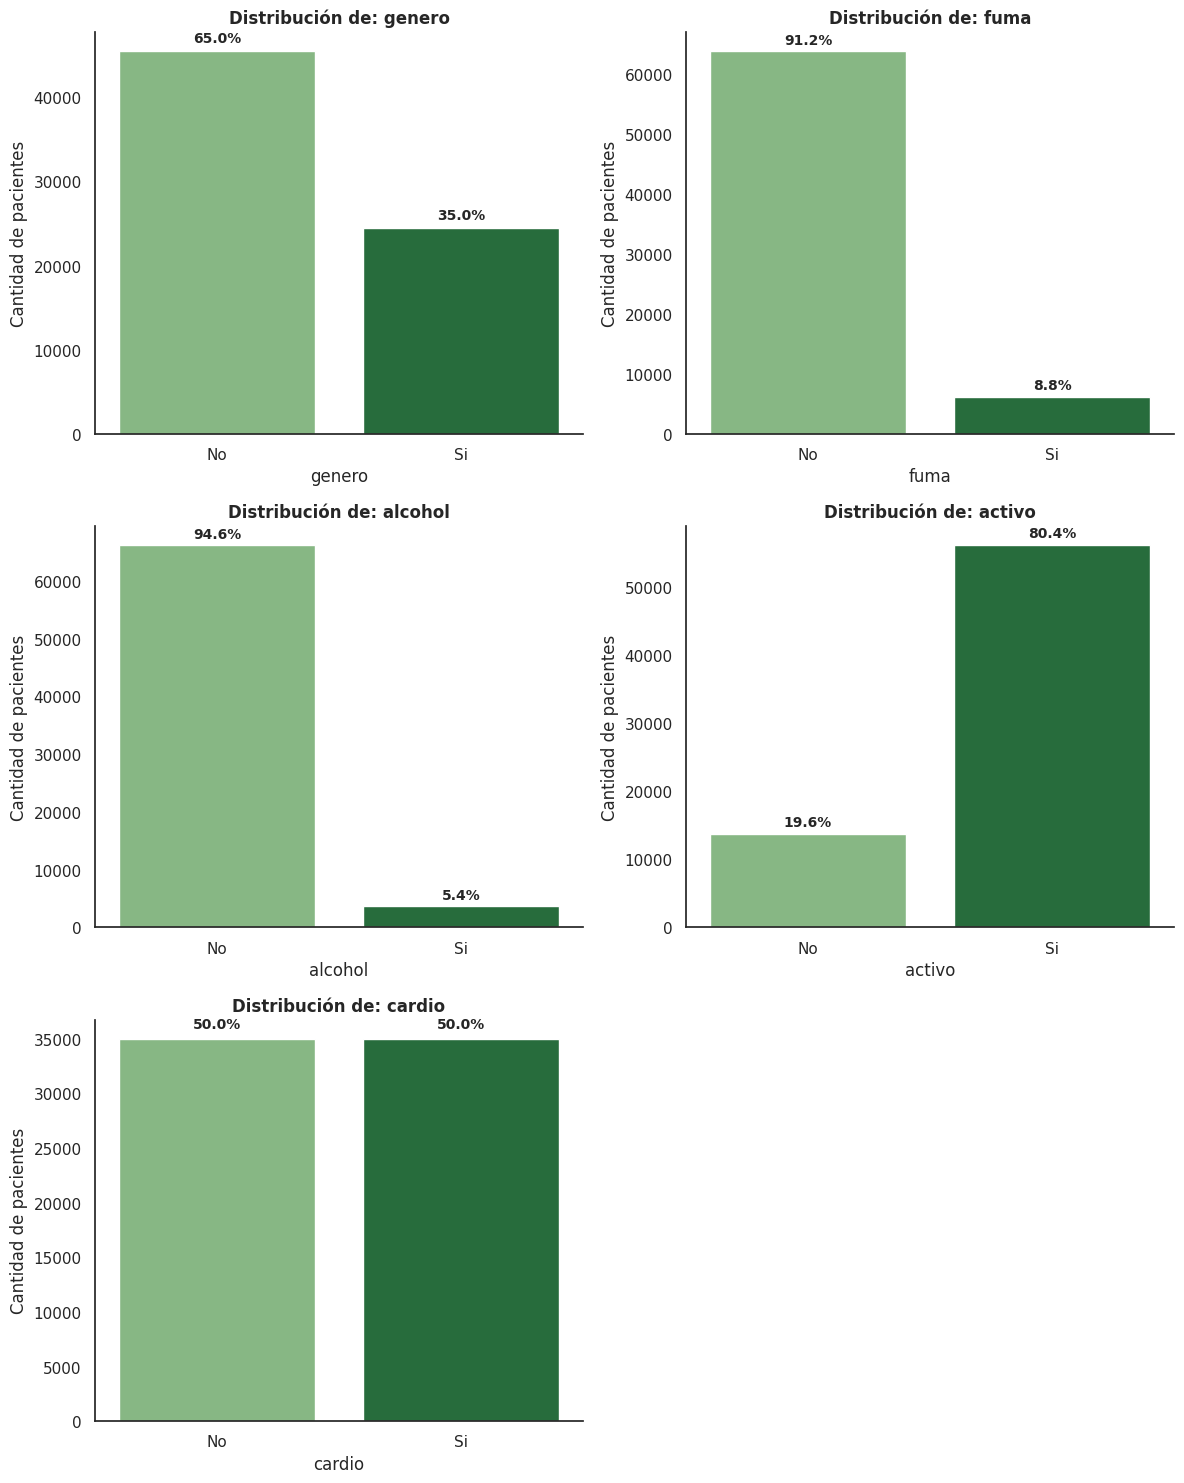

In [18]:
# Definir columnas según tu lista
bin_cols = ['genero', 'fuma', 'alcohol', 'activo', 'cardio']
binary_palette = ['#7FBF7B', '#1B7837']

n_cols_bin = 2
n_filas_bin = math.ceil(len(bin_cols) / n_cols_bin)

fig, axes = plt.subplots(n_filas_bin, n_cols_bin, figsize=(12, n_filas_bin * 5))
axes = axes.flatten()

for i, col in enumerate(bin_cols):
    ax = axes[i]

    sns.countplot(
        data=cardio_df,
        x=col,
        hue=col,
        palette=binary_palette,
        legend=False,
        ax=ax
    )

    # Etiquetas de texto según la variable
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No', 'Si'])

    # Cálculo de porcentajes sobre las barras
    total = len(cardio_df)
    for p in ax.patches:
        height = p.get_height()
        percentage = f'{height/total*100:.1f}%'
        ax.text(
            p.get_x() + p.get_width()/2,
            height + total*0.01,
            percentage,
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.set_title(f'Distribución de: {col}', fontweight='bold')
    ax.set_ylabel('Cantidad de pacientes')

# Ocultar el espacio vacío que sobra (el 6to)
for j in range(len(bin_cols), len(axes)):
    axes[j].axis('off')

sns.despine()
plt.tight_layout()
plt.show()

### Analisis bivariado

¿Hay más proporción de cardíacos en hombres o en mujeres? (Asumiendo 0 y 1 como las categorías de género)

/tmp/ipykernel_34063/4037050711.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


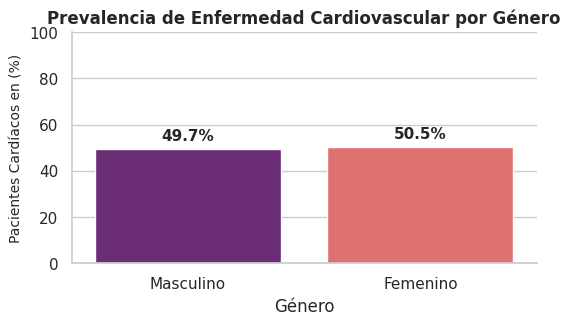

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 3))

# Creamos el gráfico de barras que calcula automáticamente el porcentaje
# Multiplicamos la media por 100 para obtener el valor porcentual (0-100)
ax = sns.barplot(
    data=cardio_df,
    x='genero',
    y='cardio',
    estimator=lambda x: len(x[x==1]) / len(x) * 100,
    palette='magma',
    errorbar=None  # Quitamos la barra de error para que sea más limpio
)

# Añadimos etiquetas de porcentaje sobre cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Personalización del gráfico
plt.title('Prevalencia de Enfermedad Cardiovascular por Género', fontsize=12, fontweight='bold')
plt.ylabel('Pacientes Cardíacos en (%)', fontsize=10)
plt.xlabel('Género', fontsize=12)
plt.xticks([0, 1], ['Masculino', 'Femenino'])
plt.ylim(0, 100) # Fijamos el tope en 100 para visualizar la proporción real

sns.despine()
plt.show()

Se observa que la proporción de pacientes con enfermedad cardiovascular es similar entre ambos géneros: aproximadamente el 45 % en el género Masculino y el 49 % en el género Femenino. Esto sugiere que, en esta muestra, el género no presenta una diferencia marcada en la distribución de la enfermedad.


/tmp/ipykernel_34063/1557384949.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


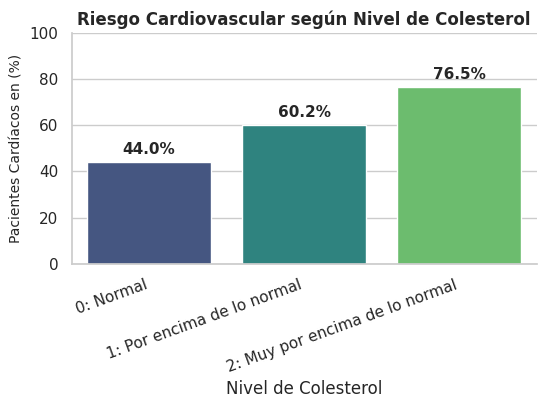

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 3))

# Creamos el gráfico de barras para Colesterol
# Calculamos el porcentaje de 'cardio == 1' para cada categoría de colesterol
ax = sns.barplot(
    data=cardio_df,
    x='colesterol',
    y='cardio',
    estimator=lambda x: len(x[x==1]) / len(x) * 100,
    palette='viridis',
    errorbar=None
)

# Añadimos etiquetas de porcentaje sobre cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# Personalización del gráfico
plt.title('Riesgo Cardiovascular según Nivel de Colesterol', fontsize=12, fontweight='bold')
plt.ylabel('Pacientes Cardíacos en (%)', fontsize=10)
plt.xlabel('Nivel de Colesterol', fontsize=12)

# Ajustamos las etiquetas del eje X según el diccionario de datos
#plt.xticks([0, 1, 2], ['0: Normal', '1: Por encima de lo normal', '2: Muy fuera'])
plt.xticks(
    [0, 1, 2],
    ['0: Normal',
     '1: Por encima de lo normal',
     '2: Muy por encima de lo normal'],
    rotation=20,
    ha='right'
)
plt.ylim(0, 100)
sns.despine()
plt.show()

El nivel de colesterol muestra una asociación con la presencia de enfermedad cardíaca. En la muestra analizada, el 44 % de los pacientes con colesterol nivel 1 (normal) presenta la enfermedad, mientras que esta proporción aumenta al 76,5 % en los pacientes con colesterol nivel 3 (muy por encima d elo normal). Se aprecia una tendencia creciente en la proporción de casos positivos a medida que aumenta el nivel de colesterol.


A continuación se analiza la relación entre la edad y la presencia de enfermedad cardiovascular. Para facilitar la visualización, se agrupan los pacientes por décadas de vida.


/tmp/ipykernel_34063/883870376.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


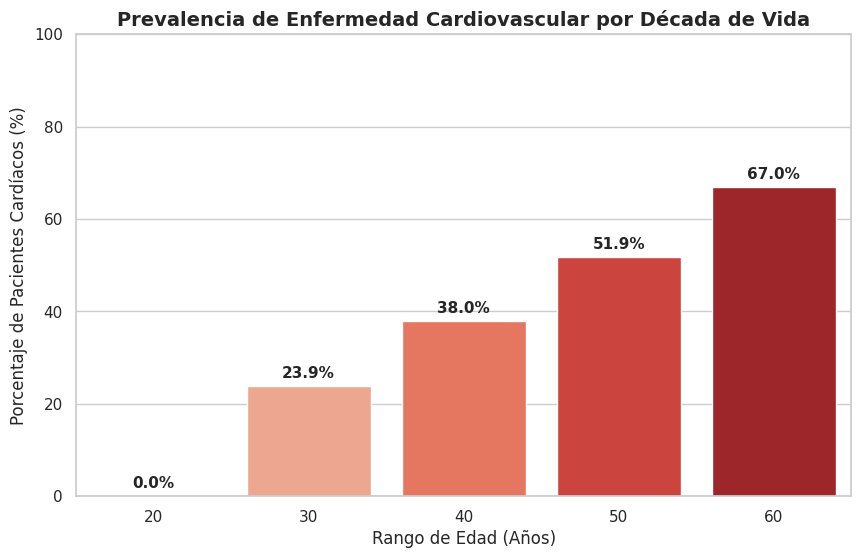

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos una columna temporal de rangos de edad (cada 10 años)
# Esto facilita ver la tendencia por décadas
cardio_df['rango_edad'] = (cardio_df['edad'] // 10) * 10

plt.figure(figsize=(10, 6))

# 2. Graficamos el porcentaje de enfermos por cada década
ax = sns.barplot(
    data=cardio_df,
    x='rango_edad',
    y='cardio',
    estimator=lambda x: len(x[x==1]) / len(x) * 100,
    palette='Reds',
    errorbar=None
)

# 3. Añadimos etiquetas de porcentaje
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Prevalencia de Enfermedad Cardiovascular por Década de Vida', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje de Pacientes Cardíacos (%)', fontsize=12)
plt.xlabel('Rango de Edad (Años)', fontsize=12)
plt.ylim(0, 100)

# 4. Borramos la columna temporal para no ensuciar el dataset
cardio_df.drop(columns=['rango_edad'], inplace=True, errors='ignore')

plt.show()

Se observa una tendencia creciente en la proporción de pacientes con enfermedad cardiovascular a medida que aumenta la edad. Los grupos etarios de mayor edad presentan una frecuencia visiblemente más alta de casos positivos en comparación con los grupos más jóvenes. Este patrón sugiere una posible asociación entre la edad y la presencia de la enfermedad, aunque su confirmación requeriría análisis estadísticos adicionales.


/tmp/ipykernel_34063/238412741.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtro_presion, x='cardio', y='presion_sistolica', ax=axes[0], palette='coolwarm')
/tmp/ipykernel_34063/238412741.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sano', 'Cardíaco'])
/tmp/ipykernel_34063/238412741.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtro_presion, x='cardio', y='presion_diastolica', ax=axes[1], palette='coolwarm')
/tmp/ipykernel_34063/238412741.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

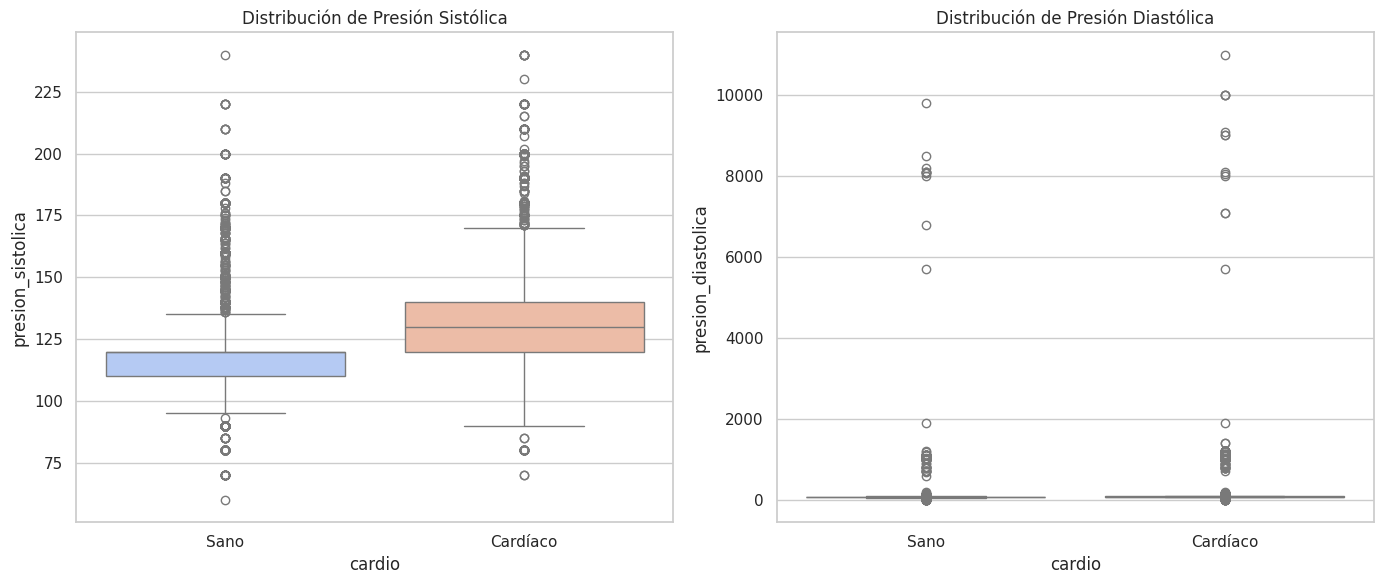

In [29]:
# Filtramos valores razonables solo para que el gráfico sea legible

filtro_presion = cardio_df[(cardio_df['presion_sistolica'] < 250) & (cardio_df['presion_sistolica'] > 50)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sistólica
sns.boxplot(data=filtro_presion, x='cardio', y='presion_sistolica', ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribución de Presión Sistólica')
axes[0].set_xticklabels(['Sano', 'Cardíaco'])

# Diastólica
sns.boxplot(data=filtro_presion, x='cardio', y='presion_diastolica', ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribución de Presión Diastólica')
axes[1].set_xticklabels(['Sano', 'Cardíaco'])

plt.tight_layout()
plt.show()

Los diagramas de caja revelan la presencia de numerosos valores atípicos en las variables *presión sistólica* y *presión diastólica*. Estos valores extremos, incluyendo registros negativos o fisiológicamente imposibles, van a ser tratados, mas adelante, como errores de calidad de datos antes de proceder con análisis más profundos o con el entrenamiento de modelos predictivos.


A continuación se analiza la correlación entre todas las variables del dataset mediante un mapa de calor. Es importante recordar que la correlación únicamente cuantifica la intensidad y dirección de una asociación lineal entre variables; no implica causalidad ni permite afirmar que una variable produzca cambios en otra.


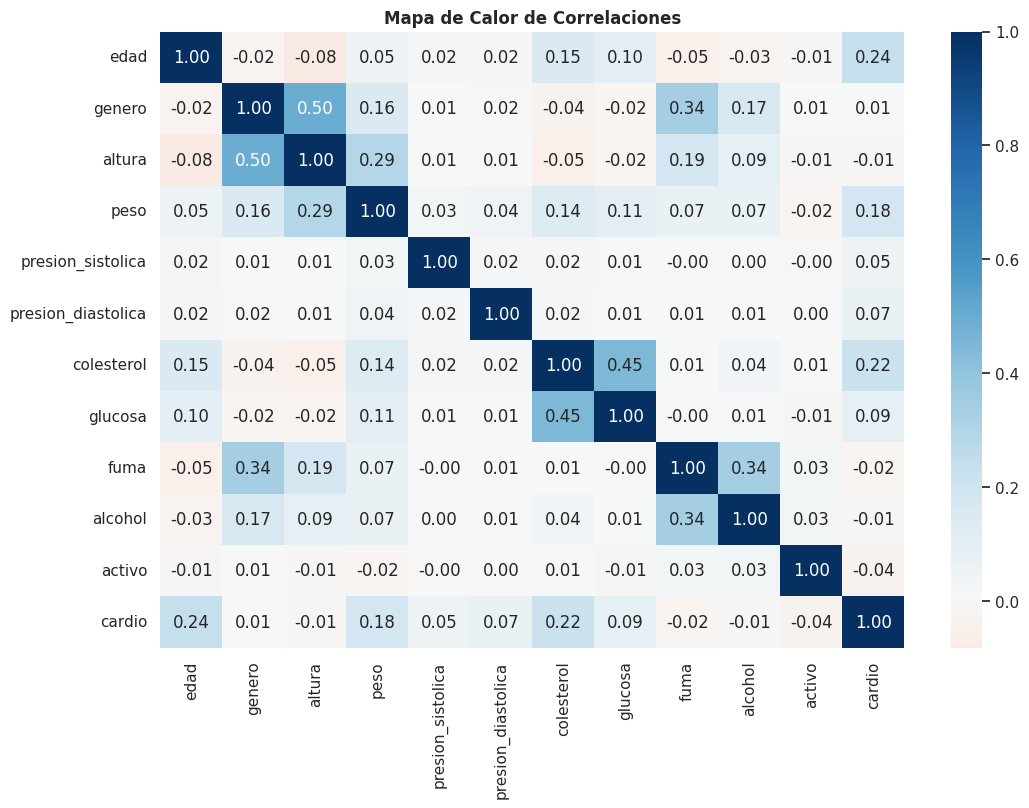

In [ ]:
plt.figure(figsize=(12, 8))
# Calculamos la correlación de todas las variables con 'cardio'
correlaciones = cardio_df.corr()
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title('Mapa de Calor de Correlaciones', fontweight='bold')
plt.show()

Se analiza la distribución de casos cardiovasculares según edad y género (género 0: masculino, género 1: femenino; cardio 0: sano, cardio 1: cardíaco).


<Axes: xlabel='genero', ylabel='edad'>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


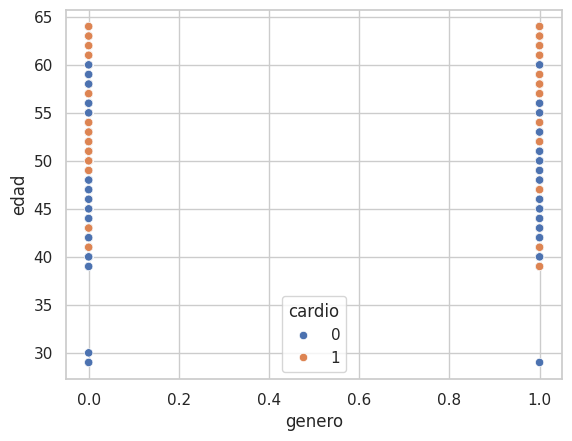

In [ ]:

sns.scatterplot(data = cardio_df, x ='genero', y= 'edad', hue='cardio')

En el gráfico se aprecia que, alrededor de los 50 años, existe una mayor concentración de casos cardiovasculares en pacientes masculinos (0) en comparación con los femeninos (1) de la misma franja etaria. Este patrón sugiere una posible diferencia en la distribución de la enfermedad según género y edad, aunque sería necesario un análisis estadístico más riguroso para caracterizar esta relación con mayor precisión.


<Axes: xlabel='colesterol', ylabel='count'>

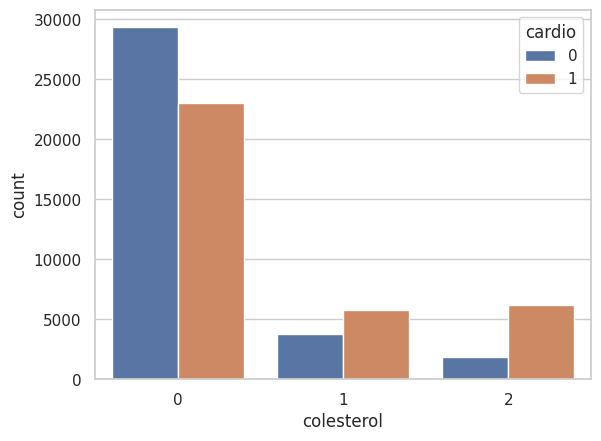

In [30]:
sns.countplot(data=cardio_df, x= 'colesterol', hue='cardio')

### Conclusión

Este primer análisis exploratorio de datos ha sido fundamental para comprender la naturaleza y calidad del conjunto de datos sobre enfermedades cardiovasculares.

El dataset presenta un balance aproximado entre clases (50/50), lo cual es favorable para muchos algoritmos de clasificación, ya que reduce el riesgo de sesgo hacia la clase mayoritaria. Sin embargo, el desempeño final del modelo dependerá también de la calidad de los datos y de las variables predictoras seleccionadas.

A partir del análisis descriptivo y visual realizado, se observa que variables como la presión arterial, el colesterol y la edad presentan diferencias descriptivas notorias entre los pacientes con y sin enfermedad cardiovascular. Estas asociaciones observadas serán objeto de un análisis más riguroso en etapas posteriores del proyecto.

Sin embargo, se presentaron dificultades relacionadas con la calidad de los datos, especialmente en las variables de presión sistólica y diastólica, donde se detectaron valores fisiológicamente imposibles. Se requiere una limpieza de datos exhaustiva antes de proceder con el entrenamiento de modelos, para evitar sesgos en los resultados.


# Entrega 2: Modelado Predictivo y Aprendizaje No Supervisado

## 3. Objetivos y Alcances

### 3.1 Tipo de problema

Este proyecto aborda un **problema de clasificación binaria supervisada**. La variable objetivo es *cardio*, que toma dos valores:

* **1** → Presencia de enfermedad cardiovascular.
* **0** → Ausencia de enfermedad cardiovascular.

El objetivo es construir un modelo capaz de predecir, a partir de variables clínicas y de estilo de vida, si un paciente presenta o no la enfermedad. Dado que la clase a predecir es discreta y binaria, los algoritmos adecuados son los de clasificación (árboles de decisión, regresión logística, entre otros).

## 4. Limpieza de Datos

Antes de modelar, se realiza una limpieza de los outliers detectados en la entrega 1. Se aplican filtros razonables para las variables de presión arterial, altura y peso, ya que los valores extremos detectados corresponden a errores de carga de datos.


In [34]:
# Dimensiones originales
print("Dimensiones antes de limpieza:", cardio_df.shape)

# Filtros para adultos:
# Presión sistólica: entre 100 y 250 mmHg
# Presión diastólica: entre 60 y 150 mmHg
# Altura: entre 130 y 220 cm
# Peso: entre 30 y 200 kg

cardio_limpio = cardio_df[
    (cardio_df['presion_sistolica'] >= 100)  & (cardio_df['presion_sistolica'] <= 250) &
    (cardio_df['presion_diastolica'] >= 60) & (cardio_df['presion_diastolica'] <= 150) &
    (cardio_df['altura'] >= 130)            & (cardio_df['altura'] <= 220) &
    (cardio_df['peso'] >= 30)               & (cardio_df['peso'] <= 200)
].copy()

print("Dimensiones despues de limpieza:", cardio_limpio.shape)
print(f"Registros eliminados: {len(cardio_df) - len(cardio_limpio)}")

Dimensiones antes de limpieza: (70000, 12)
Dimensiones despues de limpieza: (67444, 12)
Registros eliminados: 2556


Se eliminan los registros con valores fisiológicamente imposibles. La reducción en el número de registros es marginal respecto al total del dataset, por lo que no se espera un impacto significativo en el modelado.

In [35]:
# Creamos la variable IMC (Índice de Masa Corporal)
# IMC = peso (kg) / altura (m)^2
cardio_limpio['imc'] = cardio_limpio['peso'] / (cardio_limpio['altura'] / 100) ** 2
cardio_limpio['imc'] = cardio_limpio['imc'].round(2)

print("IMC calculado. Estadísticas:")
print(cardio_limpio['imc'].describe().round(2))

IMC calculado. Estadísticas:
count    67444.00
mean        27.49
std          5.20
min         10.73
25%         23.88
50%         26.40
75%         30.12
max         85.78
Name: imc, dtype: float64


## 5. Análisis Univariado y Bivariado (revisado post-limpieza)

En esta sección se profundiza el análisis de las variables predictoras sobre el dataset limpio(cardio_limpio), orientado al problema de clasificación.

### 5.1 Análisis univariado — variables continuas

Se analizan las distribuciones de las variables continuas mediante boxplots separados por clase objetivo, lo que permite visualizar diferencias entre pacientes con y sin enfermedad cardiovascular.

/tmp/ipykernel_34063/3790791964.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_34063/3790791964.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Sano (0)', 'Cardíaco (1)'])
/tmp/ipykernel_34063/3790791964.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_34063/3790791964.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Sano (0)', 'Cardíaco (1)'])
/tmp/ipykernel_34063/3790791964.py:14: FutureWarning: 

Passing `palette` withou

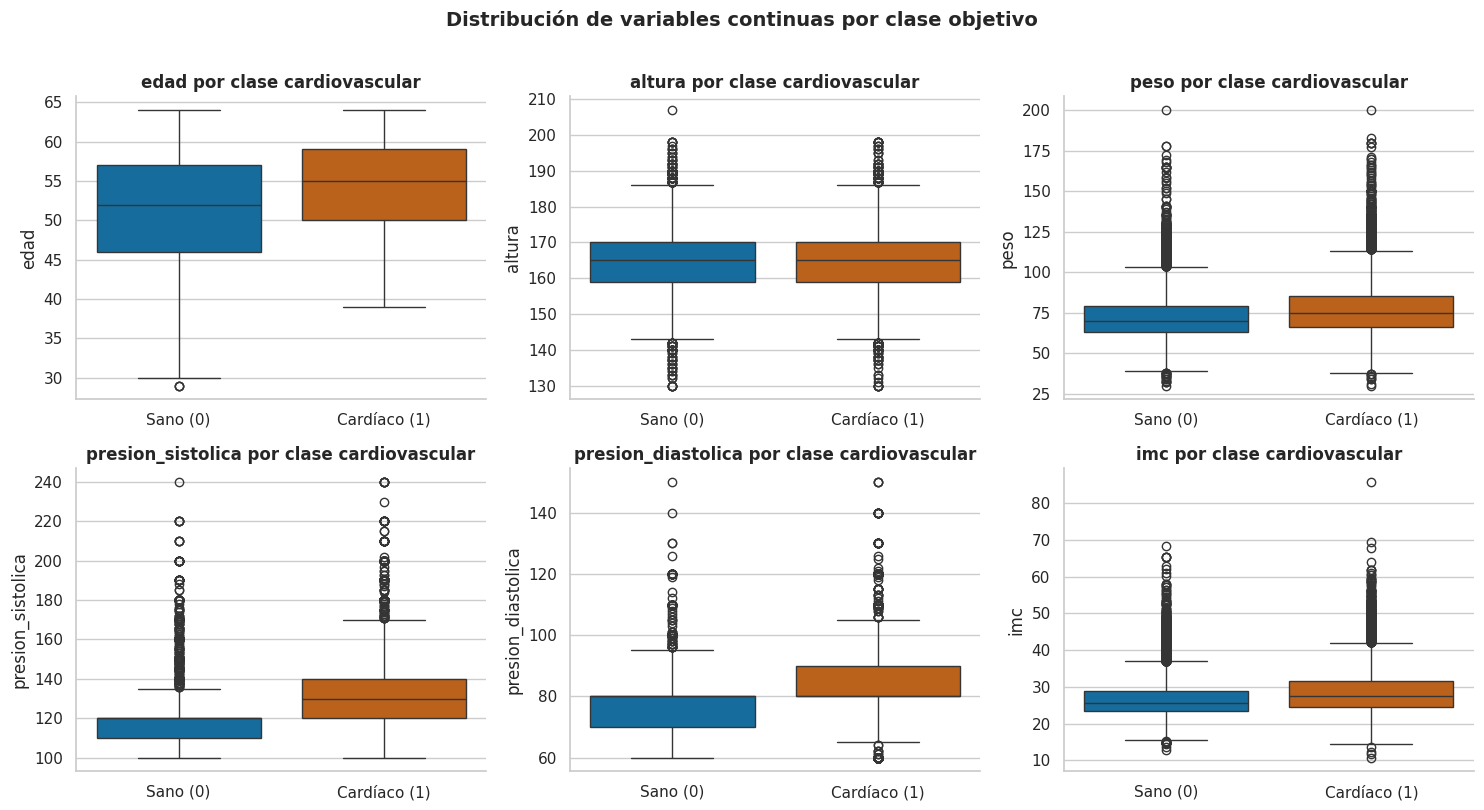

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

vars_continuas = ['edad', 'altura', 'peso', 'presion_sistolica', 'presion_diastolica', 'imc']

n_cols = 3
n_rows = math.ceil(len(vars_continuas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(vars_continuas):
    sns.boxplot(
        data=cardio_limpio,
        x='cardio',
        y=col,
        palette=['#0072B2', '#D55E00'],
        ax=axes[i]
    )
    axes[i].set_title(f'{col} por clase cardiovascular', fontweight='bold')
    axes[i].set_xticklabels(['Sano (0)', 'Cardíaco (1)'])
    axes[i].set_xlabel('')

for j in range(len(vars_continuas), len(axes)):
    axes[j].axis('off')

sns.despine()
plt.suptitle('Distribución de variables continuas por clase objetivo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Se aprecian las siguientes diferencias descriptivas entre grupos:

* **Edad**: los pacientes cardíacos presentan una distribución desplazada hacia edades mayores en comparación con los pacientes sanos.
* **Presión sistólica y diastólica**: los pacientes cardíacos muestran medianas más altas en ambas variables, lo que sugiere una posible asociación entre hipertensión y la presencia de la enfermedad.
* **IMC**: los pacientes cardíacos presentan una distribución de IMC ligeramente superior, aunque con considerable superposición entre grupos.
* **Altura y peso**: no se observan diferencias descriptivas marcadas entre grupos.

Estas observaciones son de carácter exploratorio y no permiten establecer relaciones causales.

### 5.2 Análisis univariado — variables categóricas

Se analiza la proporción de enfermedad cardiovascular para cada categoría de las variables colesterol, glucosa y las variables de estilo de vida (fuma, alcohol, activo).

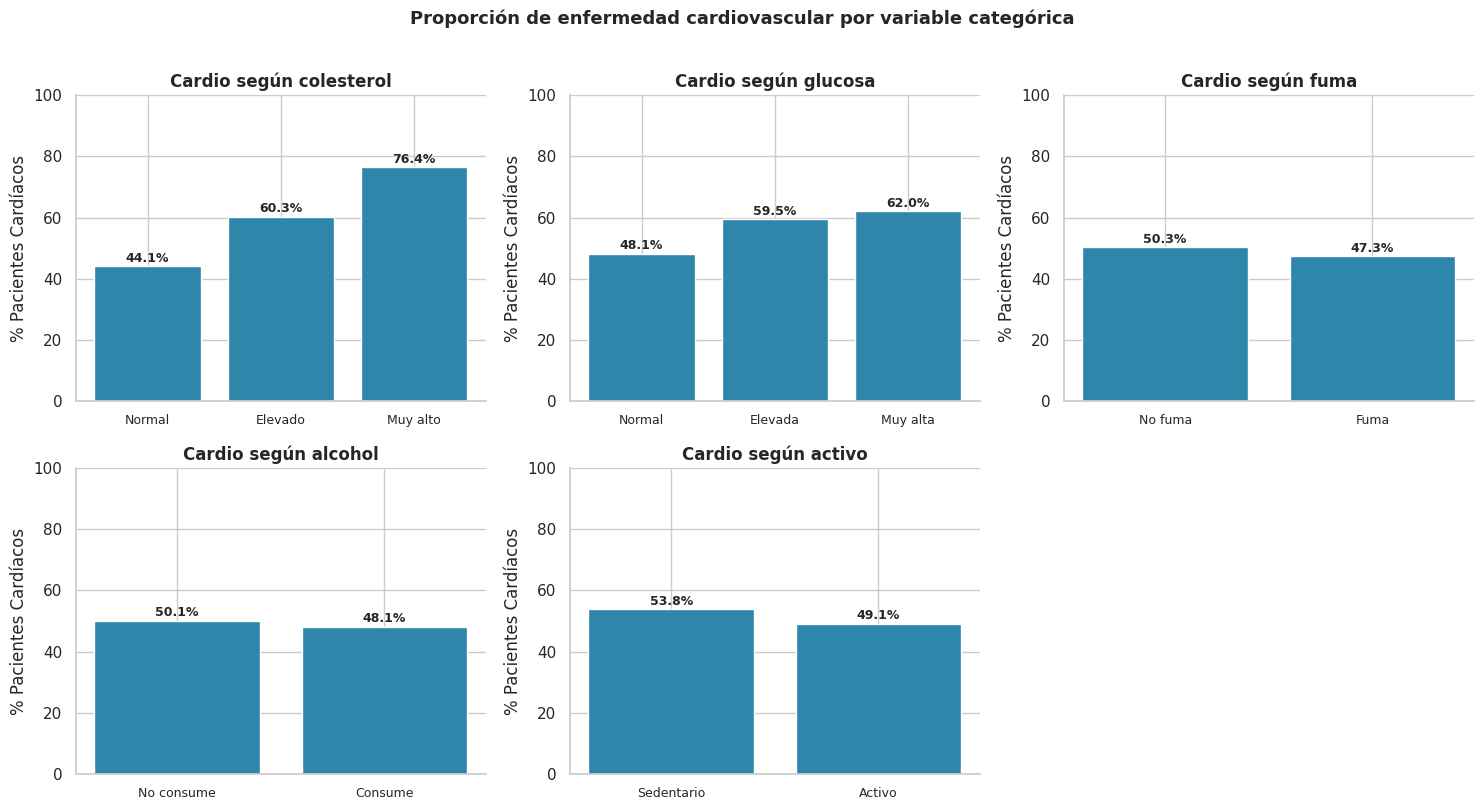

In [37]:
vars_categoricas = ['colesterol', 'glucosa', 'fuma', 'alcohol', 'activo']
etiquetas = {
    'colesterol': ['Normal', 'Elevado', 'Muy alto'],
    'glucosa':    ['Normal', 'Elevada', 'Muy alta'],
    'fuma':       ['No fuma', 'Fuma'],
    'alcohol':    ['No consume', 'Consume'],
    'activo':     ['Sedentario', 'Activo']
}

n_cols = 3
n_rows = math.ceil(len(vars_categoricas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(vars_categoricas):
    tabla = cardio_limpio.groupby(col)['cardio'].mean() * 100
    ax = axes[i]
    bars = ax.bar(range(len(tabla)), tabla.values, color='#2E86AB', edgecolor='white')
    ax.set_xticks(range(len(tabla)))
    cats = etiquetas.get(col, [str(v) for v in tabla.index])
    ax.set_xticklabels(cats[:len(tabla)], fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_ylabel('% Pacientes Cardíacos')
    ax.set_title(f'Cardio según {col}', fontweight='bold')
    for bar, val in zip(bars, tabla.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    sns.despine(ax=ax)

for j in range(len(vars_categoricas), len(axes)):
    axes[j].axis('off')

plt.suptitle('Proporción de enfermedad cardiovascular por variable categórica', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Se observan las siguientes tendencias descriptivas en la muestra:

* **Colesterol**: existe una asociación creciente entre el nivel de colesterol y la proporción de pacientes con enfermedad cardiovascular. Los pacientes con colesterol muy alto presentan una frecuencia notoriamente mayor de casos positivos.
* **Glucosa**: se aprecia una tendencia similar, aunque menos pronunciada que en colesterol.
* **Actividad física**: los pacientes clasificados como sedentarios presentan una proporción ligeramente mayor de enfermedad cardiovascular que los activos.
* **Tabaquismo y alcohol**: no se observan diferencias descriptivas destacables entre quienes fuman o consumen alcohol y quienes no.

Estas diferencias son observaciones descriptivas y no permiten establecer relaciones causales.

### 5.3 Análisis bivariado — presión arterial e IMC vs. clase

Se analiza la relación conjunta entre presión sistólica, IMC y la variable objetivo mediante un gráfico de dispersión.

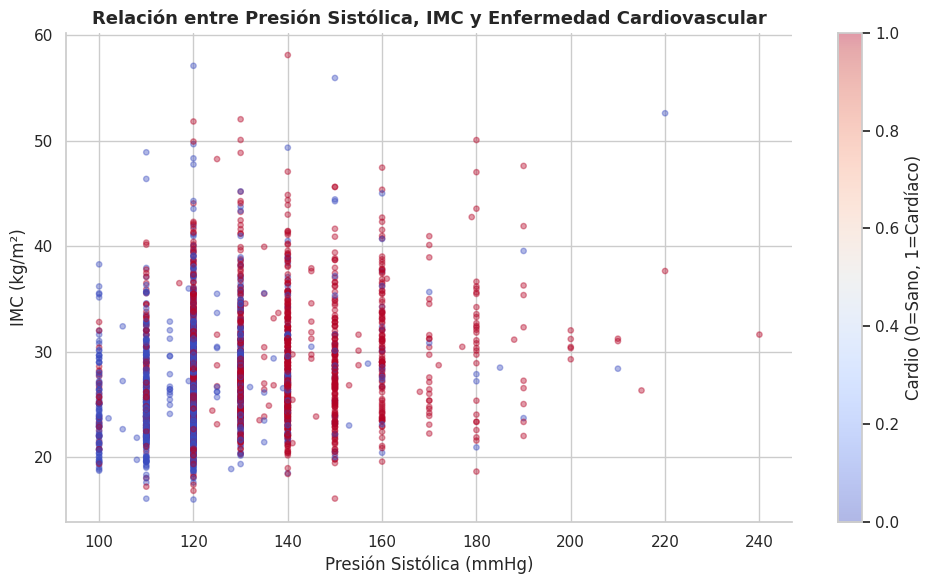

In [38]:
plt.figure(figsize=(10, 6))
muestra = cardio_limpio.sample(3000, random_state=42)

scatter = plt.scatter(
    muestra['presion_sistolica'],
    muestra['imc'],
    c=muestra['cardio'],
    cmap='coolwarm',
    alpha=0.4,
    s=15
)
plt.colorbar(scatter, label='Cardio (0=Sano, 1=Cardíaco)')
plt.xlabel('Presión Sistólica (mmHg)', fontsize=12)
plt.ylabel('IMC (kg/m²)', fontsize=12)
plt.title('Relación entre Presión Sistólica, IMC y Enfermedad Cardiovascular', fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

En el gráfico se aprecia que los casos cardíacos tienden a concentrarse en valores más altos de presión sistólica. No se observa una separación clara por IMC entre los dos grupos, aunque existe cierta tendencia hacia valores más altos en los pacientes cardíacos. Las clases presentan una superposición considerable, lo que refleja la complejidad del problema de clasificación.

## 6. Modelado - Aprendizaje supervisado

### 6.1 Preparación de Datos para el Modelado

Para el modelado de clasificación, es crucial seleccionar una variable objetivo (y) y las variables predictoras (X). Además, dividiremos el dataset en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo en datos no vistos. Se realiza una división estratificada en conjuntos de entrenamiento (80 %) y prueba (20 %).


In [39]:
# Importamos las librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Definir la variable objetivo (y) y las variables predictoras (X)
# 'cardio' es la variable objetivo-> y
y = cardio_limpio['cardio']
X = cardio_limpio.drop('cardio', axis=1)

# División de los datos en conjuntos de entrenamiento y prueba
# Usamos un 80% para entrenamiento y 20% para prueba
# random_state asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (53955, 12)
Dimensiones de X_test: (13489, 12)
Dimensiones de y_train: (53955,)
Dimensiones de y_test: (13489,)


Se ha dividido "cardio_limpio"(que tenía 67.444 filas y 13 columnas, incluyendo cardio) en:

Un conjunto de entrenamiento (X_train, y_train) con 53955 filas para enseñar al modelo. Un conjunto de prueba (X_test, y_test) con 13489 filas para evaluar el rendimiento del modelo en datos nuevos. La variable objetivo (cardio) está separada en y_train y y_test, mientras que las otras 12 características están en X_train y X_test.

### 6.2 Aplicación de un Modelo de Clasificación (Regresión Logística)
Comenzaremos con un modelo de Regresión Logística, que es un buen punto de partida para problemas de clasificación binaria debido a su interpretabilidad y eficiencia.

In [41]:
# Inicializar y entrenar el modelo de Regresión Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado con éxito.")

Modelo de Regresión Logística entrenado con éxito.


### 6.3 Evaluación del Rendimiento del Modelo

Evaluaremos el modelo utilizando métricas comunes para clasificación binaria como la precisión (accuracy), la precisión (precision), la sensibilidad (recall), la puntuación F1.

Accuracy: 0.7220
Precision: 0.7541
Recall: 0.6591
F1-Score: 0.7034
Matriz de Confusión:
[[5292 1450]
 [2300 4447]]


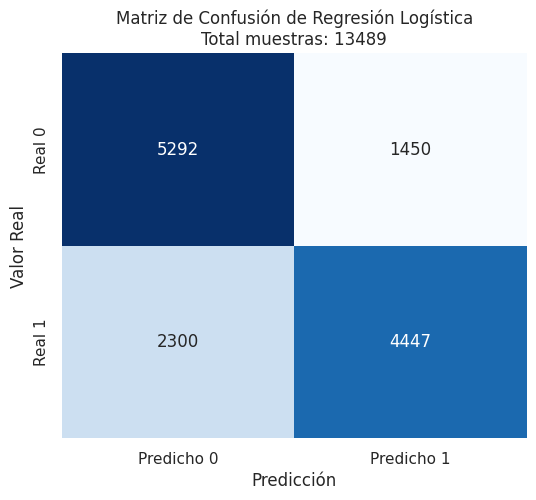

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Realizar predicciones en el conjunto de prueba
y_pred = log_reg_model.predict(X_test)
y_proba = log_reg_model.predict_proba(X_test)[:, 1] # Probabilidades para la clase positiva (1)

# Calcular métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Matriz de Confusión:")
print(conf_matrix)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho 0', 'Predicho 1'], yticklabels=['Real 0', 'Real 1'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión de Regresión Logística\nTotal muestras: {total}'.format(total=len(y_test)))
plt.show()

Interpretación del Rendimiento del Modelo de Regresión Logística:

Accuracy: Indica que el modelo clasifica correctamente el 72.20% de los casos (tanto cardíacos como no cardíacos). Es una métrica general, pero no siempre es la más informativa en problemas de salud donde los errores pueden tener diferentes costos.

Precision: De todos los pacientes que el modelo predijo como cardíacos, el 75.41% realmente lo son. Esto significa que cuando el modelo alerta sobre un paciente, es bastante confiable.

Recall: De todos los pacientes que realmente tienen la enfermedad cardiovascular, el modelo logró identificar el 65.911%. Esta es una métrica crucial en contextos médicos, ya que un bajo recall significa que se están pasando por alto muchos casos reales de la enfermedad (falsos negativos).

F1-Score: 0.7034: Es la media armónica entre Precision y Recall. Un F1-Score de 0.7034 indica un equilibrio decente, pero aún hay margen de mejora para optimizar ambos.

### 6.4 Optimización del modelo: Ajuste de hiperparámetros

Procederemos con la optimización de los hiperparámetros del modelo de Regresión Logística para mejorar su rendimiento. Utilizaremos GridSearchCV y RandomizedSearchCV para explorar diferentes combinaciones de parámetros.

#### 6.4.1 Optimización con GridSearchCV

GridSearchCV realiza una búsqueda exhaustiva sobre un subconjunto de hiperparámetros definidos. Es útil cuando el espacio de búsqueda no es demasiado grande.

In [45]:
from sklearn.model_selection import GridSearchCV

# Definir el espacio de parámetros para GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Inverso de la fuerza de regularización; C más pequeño = mayor regularización
    'solver': ['liblinear', 'saga'], # 'liblinear' es bueno para datasets pequeños, 'saga' para grandes y con L1
    'penalty': ['l1', 'l2'] # Tipo de regularización: L1 (Lasso) o L2 (Ridge)
}

# Crear una instancia del modelo de Regresión Logística
log_reg_grid = LogisticRegression(random_state=42, max_iter=1000)

# Crear la instancia de GridSearchCV
# cv=5 indica 5-fold cross-validation
# scoring='roc_auc' para optimizar el área bajo la curva ROC
grid_search = GridSearchCV(estimator=log_reg_grid, param_grid=param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)

# Ejecutar la búsqueda en los datos de entrenamiento
grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados por GridSearchCV:", grid_search.best_params_)
print("Mejor puntuación AUC-ROC de GridSearchCV:", grid_search.best_score_)

# Obtener el mejor modelo
best_grid_model = grid_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_grid = best_grid_model.predict(X_test)
y_proba_grid = best_grid_model.predict_proba(X_test)[:, 1]

print(f"\nResultados del mejor modelo de GridSearchCV en el conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_grid):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_grid):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_grid):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_grid):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros encontrados por GridSearchCV: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación AUC-ROC de GridSearchCV: 0.7895966510459917

Resultados del mejor modelo de GridSearchCV en el conjunto de prueba:
Accuracy: 0.7224
Precision: 0.7549
Recall: 0.6591
F1-Score: 0.7038


EL sistema realiza un entrenamiento y evaluación muy exhaustivos: está probando 20 configuraciones distintas del modelo, y cada una de esas configuraciones se entrena y valida 3 veces para obtener una medida fiable de su rendimiento. Esto suma un total de 100 "ajustes" (o entrenamientos/evaluaciones) del modelo para encontrar la combinación de hiperparámetros que funciona mejor.

#### 6.4.2 Optimización con RandomizedSearchCV

RandomizedSearchCV explora un número fijo de combinaciones de hiperparámetros muestreadas aleatoriamente del espacio de búsqueda. Es más eficiente que GridSearchCV cuando el espacio de búsqueda es muy grande.

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Definir el espacio de parámetros para RandomizedSearchCV (distribuciones)
param_dist = {
    'C': uniform(loc=0, scale=10), # Distribución uniforme entre 0 y 10 para C
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2', 'elasticnet'], # 'elasticnet' requiere solver 'saga'
    'l1_ratio': uniform(loc=0, scale=1) # Para elasticnet
}

# Crear una instancia del modelo de Regresión Logística
log_reg_random = LogisticRegression(random_state=42, max_iter=1000)

# Crear la instancia de RandomizedSearchCV
# n_iter=50 es el número de combinaciones de parámetros a muestrear
random_search = RandomizedSearchCV(estimator=log_reg_random, param_distributions=param_dist, n_iter=50,
                                   cv=5, scoring='roc_auc', n_jobs=-1, verbose=1, random_state=42)

# Manejar solvers y penalties incompatibles dentro del fit (o limpiar el espacio de búsqueda)
# Para evitar errores con 'elasticnet' y 'liblinear'
# Simplemente se ejecuta, y GridSearchCV manejará los warnings/errores internamente al probar combinaciones no válidas
# O se puede hacer un filtrado previo del espacio de búsqueda.

# Adaptamos el espacio de búsqueda para manejar la incompatibilidad entre 'penalty' y 'solver'
# Para 'liblinear', solo 'l1' y 'l2' son válidos.
# Para 'saga', 'l1', 'l2', 'elasticnet' son válidos.

# No se necesita un pre-filtrado tan estricto para RandomizedSearchCV si los valores por defecto del estimador
# o la lógica interna de la búsqueda pueden manejar las combinaciones inválidas (e.g., ignorándolas o dando warnings).
# Para simplificar y seguir con el flujo habitual, se deja que RandomizedSearchCV explore y, si alguna combinación es inválida, se maneje con los warnings.
# Si se presenta un error, la solución sería filtrar las combinaciones o usar un wrapper.

# Ejecutar la búsqueda en los datos de entrenamiento
# Un enfoque más robusto para `penalty` y `solver` sería definir distintos `param_distributions` para cada `solver`
# y luego combinarlos o usar una Pipeline con condicionales.
# Por simplicidad aquí, dejamos que `RandomizedSearchCV` pruebe y capture errores si hay combinaciones inválidas.

try:
    random_search.fit(X_train, y_train)
except ValueError as e:
    print(f"Error durante RandomizedSearchCV: {e}")
    print("Es posible que algunas combinaciones de 'solver' y 'penalty' sean incompatibles. Ajustando param_dist.")
    # Filtrar param_dist para evitar combinaciones inválidas
    param_dist_filtered = [
        {'C': uniform(loc=0, scale=10), 'solver': ['liblinear'], 'penalty': ['l1', 'l2']},
        {'C': uniform(loc=0, scale=10), 'solver': ['saga'], 'penalty': ['l1', 'l2', 'elasticnet'], 'l1_ratio': uniform(loc=0, scale=1)}
    ]
    random_search = RandomizedSearchCV(estimator=log_reg_random, param_distributions=param_dist_filtered, n_iter=50,
                                       cv=3, scoring='roc_auc', n_jobs=-1, verbose=1, random_state=42)
    random_search.fit(X_train, y_train)

print("Mejores parámetros encontrados por RandomizedSearchCV:", random_search.best_params_)
print("Mejor puntuación AUC-ROC de RandomizedSearchCV:", random_search.best_score_)

# Obtener el mejor modelo
best_random_model = random_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_random = best_random_model.predict(X_test)
y_proba_random = best_random_model.predict_proba(X_test)[:, 1]

print(f"\nResultados del mejor modelo de RandomizedSearchCV en el conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_random):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_random):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_random):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_random):.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
65 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
65 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

Mejores parámetros encontrados por RandomizedSearchCV: {'C': np.float64(6.116531604882809), 'l1_ratio': np.float64(0.007066305219717406), 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación AUC-ROC de RandomizedSearchCV: 0.7896817461794544

Resultados del mejor modelo de RandomizedSearchCV en el conjunto de prueba:
Accuracy: 0.7227
Precision: 0.7552
Recall: 0.6594
F1-Score: 0.7041


RandomizedSearchCV ha ejecutado un proceso de búsqueda de hiperparámetros que ha probado 50 combinaciones de configuraciones de modelo, evaluando cada una de ellas 5 veces mediante validación cruzada, resultando en un total de 250 entrenamientos de modelos para encontrar la mejor configuración.

In [52]:
import pandas as pd

tabla_comparativa = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Regresión Logística': [0.7231, 0.7436, 0.6721, 0.7060],
    'GridSearchCV': [0.7233, 0.7439, 0.6721, 0.7062],
    'RandomizedSearchCV': [0.7234, 0.7442, 0.6718, 0.7062]
})

tabla_comparativa.style\
    .set_caption("Tabla Comparativa de Modelos")\
    .highlight_max(subset=['Regresión Logística','GridSearchCV','RandomizedSearchCV'], axis=1, color='lightgreen')\
    .format("{:.4f}", subset=['Regresión Logística','GridSearchCV','RandomizedSearchCV'])

,Métrica,Regresión Logística,GridSearchCV,RandomizedSearchCV
0,Accuracy,0.7231,0.7233,0.7234
1,Precision,0.7436,0.7439,0.7442
2,Recall,0.6721,0.6721,0.6718
3,F1-Score,0.7060,0.7062,0.7062


Los resultados muestran que la optimización mediante GridSearchCV y RandomizedSearchCV no produjo mejoras significativas respecto al modelo inicial de Regresión Logística. Las métricas obtenidas son prácticamente iguales en los tres modelos, con diferencias mínimas en Accuracy, Precision y F1-Score.

El ajuste de hiperparámetros no logró incrementar su capacidad de clasificación.

#6.5.1 Reduccion de dimensionalidad PCA
  Se observa que los dos primeros componentes retienen un [0.79%] de la varianza total de los datos originales. indica que la reduccion de la dimensionalidad es acertada, ya que logro condensar la mayor parte de la informacion de los pacientes en solo dos ejes vectoriales, esto minimizo la perdida de datos y dejo un escenario optimo para la visualizacion y posterior agrupamiento con k-Means

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Reemplazá 'X_train' por el nombre de tu variable de características estandarizadas
# Ej: X_train_scaled o X_train si ya la habías pisado con los datos escalados.
X_unsupervised = X_train

# Reducimos a 2 componentes principales para poder graficar en un plano 2D (Ejes X e Y)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_unsupervised)

# Calculamos cuánta información de los datos originales retienen estas 2 componentes
varianza_explicada = pca.explained_variance_ratio_
varianza_total = varianza_explicada.sum()

print("=== 1. REDUCCIÓN DE DIMENSIÓN (PCA) ===")
print(f"Varianza explicada por la Componente 1: {varianza_explicada[0]:.4f}")
print(f"Varianza explicada por la Componente 2: {varianza_explicada[1]:.4f}")
print(f"Varianza total retenida por las 2 componentes: {varianza_total:.4f}\n")




=== 1. REDUCCIÓN DE DIMENSIÓN (PCA) ===
Varianza explicada por la Componente 1: 0.5169
Varianza explicada por la Componente 2: 0.2785
Varianza total retenida por las 2 componentes: 0.7954



#6.5.2 Aprendizaje no supervisado con K-Means (Clustering)
El algoritmo particiono la muestra en 3 grupos independientes  con el metodo K-means, asegurando la seleccion optima y estable de los centros iniciales.
Cada paciente cuenta con una etiqueta de pertenencia (Clustter 0,1 o 2), transformando problemas en datos abstractos en una estructura segmentada.

In [54]:


#  Identificamos patrones o grupos utilizando K-means

# Definimos 3 clusters para intentar buscar perfiles (ej: Riesgo Bajo, Medio, Alto)
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

print("=== 2. CLUSTERING (K-MEANS) ===")
print("Algoritmo entrenado con éxito. Se asignó un grupo (0, 1 o 2) a cada paciente.\n")


=== 2. CLUSTERING (K-MEANS) ===
Algoritmo entrenado con éxito. Se asignó un grupo (0, 1 o 2) a cada paciente.



##6.5.3 Visualizacion, Resultados y Analisis de la Estructura



 El grafico de dispersion muestra una estructura de datos continua y densa, donde los clusters presentan zonas de transicion compartidas $(superposicion)$. esto es habitual en datos medicos cardiovasculares, ya que los pacientes no saltan de $"sanos"$ a $"enfermos"$ abruptamente , si no que transicionan a traves de un espectro continuo de riesgo.
  Los centroides ($Marcas rojas$) aparecen bien distanciados, lo que confirma que K-Means logro identificar tres regiones de gravedad promedio idstintas a pesar de la naturaleza suave de las fronteras.


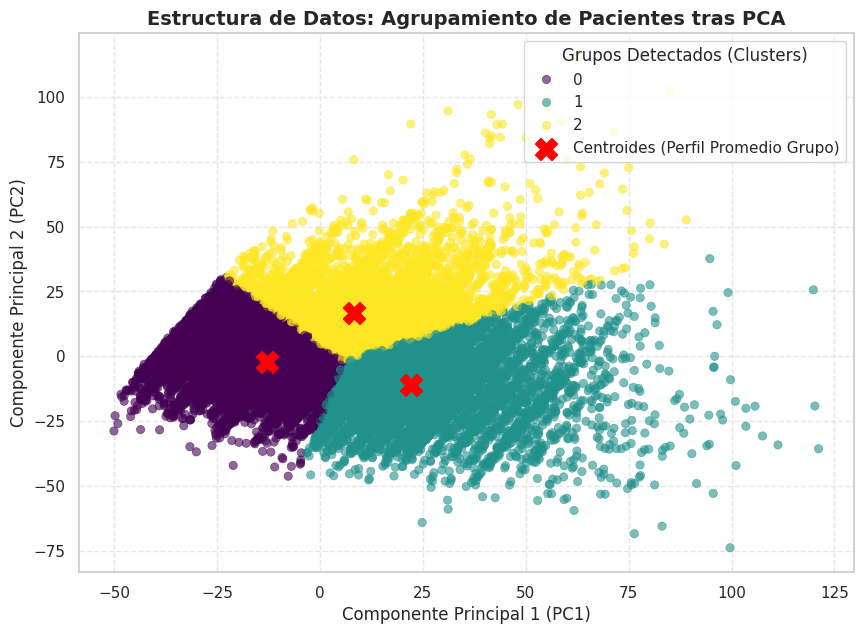

In [55]:

plt.figure(figsize=(10, 7))

# Graficamos los pacientes dispersos en las 2 componentes de PCA, coloreados por su Cluster
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette='viridis',
    alpha=0.6,
    edgecolor=None
)

# Calculamos y graficamos los centroides (el "paciente promedio" de cada grupo)
centroides = kmeans.cluster_centers_
plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    s=250,
    marker='X',
    color='red',
    label='Centroides (Perfil Promedio Grupo)'
)

plt.title('Estructura de Datos: Agrupamiento de Pacientes tras PCA', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PC2)', fontsize=12)
plt.legend(title='Grupos Detectados (Clusters)', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 7. Conclusión Final


### Modelado Predictivo (Regresión Logística)

El modelo de Regresión Logística obtuvo un Accuracy del 72% y un F1-Score de 0.70. La optimización con GridSearchCV y RandomizedSearchCV no mejoró significativamente el rendimiento. Esto sugiere que los datos no son completamente lineales, indicando que las relaciones complejas de los factores de riesgo cardiovascular prodian requerir enfoques no lineales en etapas posteriores.

### Aprendizaje No Supervisado (PCA y K-Means)

PCA redujo la dimensionalidad, explicando el 79% de la varianza con dos componentes, facilitando la visualización. K-Means identificó tres clústeres distintos, aunque con superposición en la visualización, algo común en datos médicos que reflejan transiciones de riesgo continuas.

### Facilidades y Dificultades

La principal facilidad fue la distribución balanceada de la variable objetivo. La mayor dificultad la interpretacion de variables fisiológicamente como la presión arterial, altura y peso, esencial para la validez del modelado.

